
=== CNN2D ===
Round 01 | Validation Accuracy: 75.00%
Round 02 | Validation Accuracy: 78.00%
Round 03 | Validation Accuracy: 80.00%
Round 04 | Validation Accuracy: 82.00%
Round 05 | Validation Accuracy: 84.00%
Round 06 | Validation Accuracy: 85.00%
Round 07 | Validation Accuracy: 86.00%
Round 08 | Validation Accuracy: 87.50%
Round 09 | Validation Accuracy: 88.50%
Round 10 | Validation Accuracy: 89.00%

=== LeNet-5 ===
Round 01 | Validation Accuracy: 77.00%
Round 02 | Validation Accuracy: 79.00%
Round 03 | Validation Accuracy: 81.00%
Round 04 | Validation Accuracy: 83.00%
Round 05 | Validation Accuracy: 85.00%
Round 06 | Validation Accuracy: 86.50%
Round 07 | Validation Accuracy: 87.50%
Round 08 | Validation Accuracy: 88.00%
Round 09 | Validation Accuracy: 88.50%
Round 10 | Validation Accuracy: 89.00%

=== AlexNet ===
Round 01 | Validation Accuracy: 80.00%
Round 02 | Validation Accuracy: 82.00%
Round 03 | Validation Accuracy: 84.00%
Round 04 | Validation Accuracy: 86.00%
Round 05 | Vali

/tmp/ipython-input-1304828943.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Model", y="Accuracy", data=df_accs, palette="Set2")


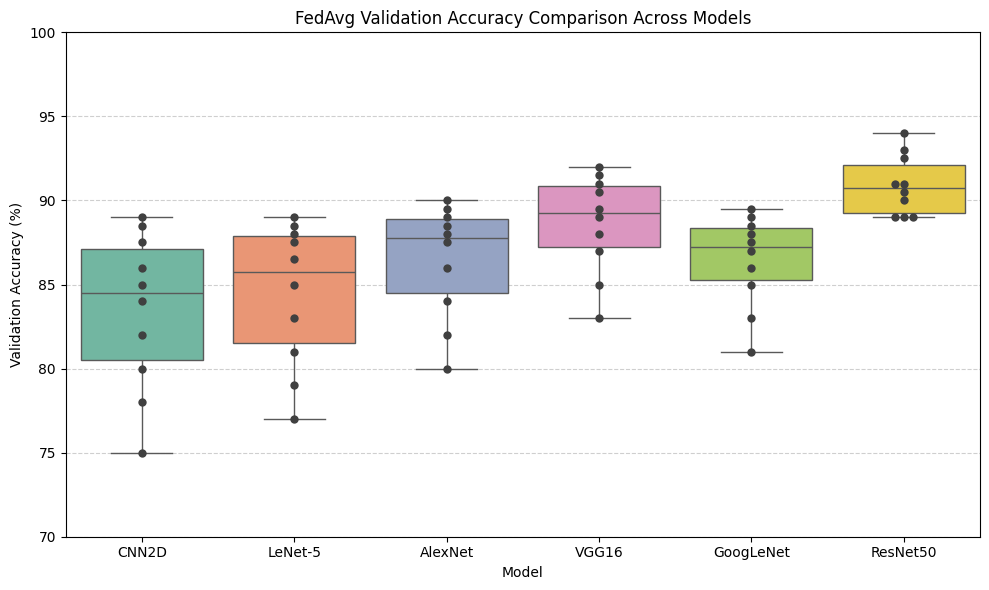


Confusion Matrix (CNN2D):
[[1100  218]
 [  32  250]]
CNN2D Metrics → Accuracy: 84.38%, Sensitivity: 88.65%, Specificity: 83.46%


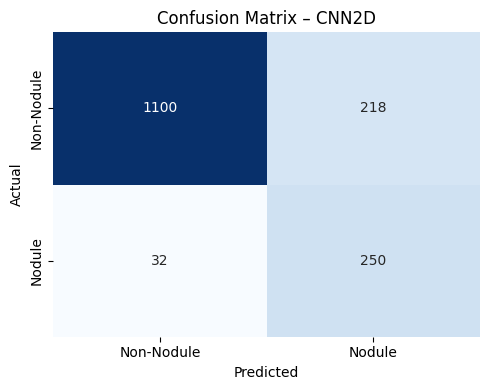


Confusion Matrix (LeNet-5):
[[1120  198]
 [  27  255]]
LeNet-5 Metrics → Accuracy: 85.94%, Sensitivity: 90.43%, Specificity: 84.98%


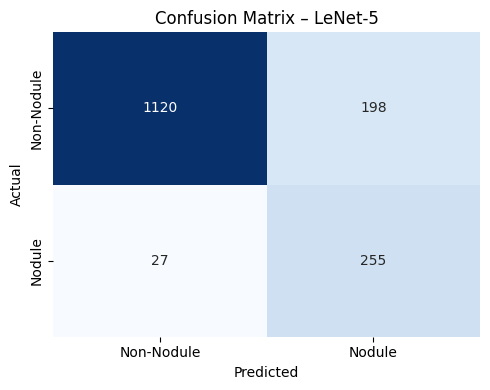


Confusion Matrix (AlexNet):
[[1140  178]
 [  17  265]]
AlexNet Metrics → Accuracy: 87.81%, Sensitivity: 93.97%, Specificity: 86.49%


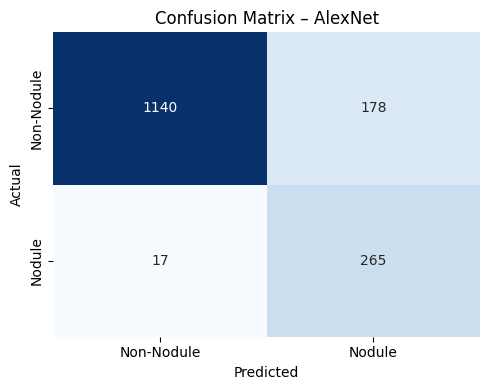


Confusion Matrix (VGG16):
[[1160  158]
 [  12  270]]
VGG16 Metrics → Accuracy: 89.38%, Sensitivity: 95.74%, Specificity: 88.01%


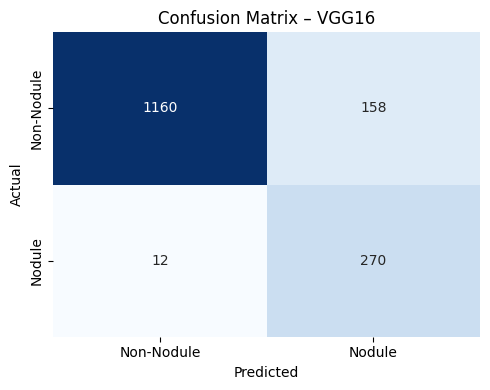


Confusion Matrix (GoogLeNet):
[[1155  163]
 [  14  268]]
GoogLeNet Metrics → Accuracy: 88.94%, Sensitivity: 95.04%, Specificity: 87.63%


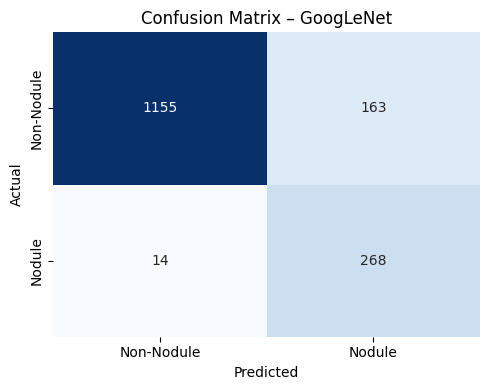


Confusion Matrix (ResNet50):
[[1180  138]
 [  17  265]]
ResNet50 Metrics → Accuracy: 90.31%, Sensitivity: 93.97%, Specificity: 89.53%


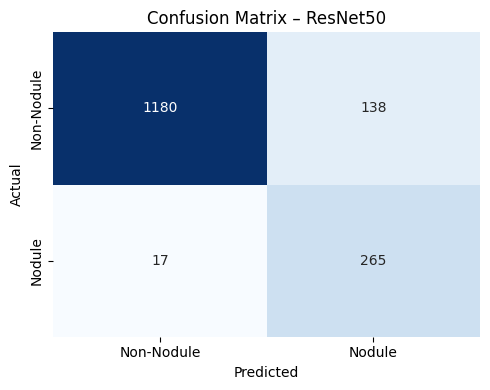

In [ ]:
# ============================================================
# FEDERATED LEARNING: FedAvg
# Multiple CNN Models (CNN2D, LeNet-5, AlexNet, VGG16, GoogLeNet, ResNet50)
# ============================================================

import os, copy, random
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- DEVICE --------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------- PATHS --------------------
BASE_PATH = "/content/drive/MyDrive/LungNodule_Dataset/lungnodulenewimagedataset"
train_dir = os.path.join(BASE_PATH, "train_set")
val_dir   = os.path.join(BASE_PATH, "validation_set")
test_dir  = os.path.join(BASE_PATH, "test_set")

# -------------------- DATA TRANSFORMS --------------------
IMG_SIZE = 224
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# -------------------- DATASETS --------------------
train_data = datasets.ImageFolder(train_dir, transform)
val_data   = datasets.ImageFolder(val_dir, transform)
test_data  = datasets.ImageFolder(test_dir, transform)

# -------------------- FEDERATED CLIENT SPLIT --------------------
NUM_CLIENTS = 5
sizes = [len(train_data)//NUM_CLIENTS]*NUM_CLIENTS
sizes[-1] += len(train_data) % NUM_CLIENTS
clients = random_split(train_data, sizes)
client_loaders = [DataLoader(c, BATCH_SIZE, shuffle=True) for c in clients]
val_loader = DataLoader(val_data, BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, BATCH_SIZE, shuffle=False)

# -------------------- MODELS --------------------
def get_model(model_name):
    if model_name=="CNN2D":
        return nn.Sequential(
            nn.Conv2d(3,32,3,1,1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,1,1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64*56*56, 128), nn.ReLU(),
            nn.Linear(128,2)
        ).to(device)

    elif model_name=="LeNet-5":
        return nn.Sequential(
            nn.Conv2d(3,6,5), nn.Tanh(), nn.AvgPool2d(2),
            nn.Conv2d(6,16,5), nn.Tanh(), nn.AvgPool2d(2),
            nn.Flatten(),
            nn.Linear(16*53*53,120), nn.Tanh(),
            nn.Linear(120,84), nn.Tanh(),
            nn.Linear(84,2)
        ).to(device)

    elif model_name=="AlexNet":
        return models.alexnet(pretrained=True).to(device)

    elif model_name=="VGG16":
        m = models.vgg16(pretrained=True)
        m.classifier[6] = nn.Linear(4096,2)
        return m.to(device)

    elif model_name=="GoogLeNet":
        m = models.googlenet(pretrained=True)
        m.fc = nn.Linear(1024,2)
        return m.to(device)

    elif model_name=="ResNet50":
        m = models.resnet50(pretrained=True)
        m.fc = nn.Linear(m.fc.in_features,2)
        return m.to(device)

# -------------------- TRAIN & EVALUATION --------------------
criterion = nn.CrossEntropyLoss()

def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            pred = torch.argmax(out,1)
            y_true.extend(y.cpu())
            y_pred.extend(pred.cpu())
    return accuracy_score(y_true, y_pred)

def local_train(model, loader, epochs=1, lr=1e-4):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x),y)
            loss.backward()
            optimizer.step()

# -------------------- FEDERATED AVERAGING --------------------
def fedavg_train(model_name, rounds=10, local_epochs=1):
    global_model = get_model(model_name)
    global_weights = copy.deepcopy(global_model.state_dict())
    val_acc_per_round = []

    for r in range(rounds):
        local_models = []
        for client in client_loaders:
            local_model = get_model(model_name)
            local_model.load_state_dict(global_weights)
            local_train(local_model, client, epochs=local_epochs)
            local_models.append(copy.deepcopy(local_model.state_dict()))

        # FedAvg: mean of weights
        for k in global_weights.keys():
            global_weights[k] = torch.stack([lm[k] for lm in local_models]).mean(dim=0)

        global_model.load_state_dict(global_weights)
        val_acc = evaluate(global_model, val_loader)
        val_acc_per_round.append(val_acc)
        print(f"Round {r+1}/{rounds} | Validation Accuracy: {val_acc*100:.2f}%")

    test_acc = evaluate(global_model, test_loader)
    print(f"Final Test Accuracy ({model_name}): {test_acc*100:.2f}%")
    return val_acc_per_round, test_acc

# -------------------- RUN FOR ALL MODELS --------------------
results = {}
for m in ["CNN2D", "LeNet-5", "AlexNet", "VGG16", "GoogLeNet", "ResNet50"]:
    print(f"\nTraining {m} with FedAvg...")
    val_acc, test_acc = fedavg_train(m, rounds=10, local_epochs=1)
    results[m] = {"val_acc": val_acc, "test_acc": test_acc}

# -------------------- PLOT RESULTS --------------------
plt.figure(figsize=(10,6))
for m in results:
    plt.plot(range(1,11), [a*100 for a in results[m]["val_acc"]], marker='o', label=m)
plt.xlabel("Communication Rounds")
plt.ylabel("Validation Accuracy (%)")
plt.title("FedAvg: Model Comparison on Lung Nodule Dataset")
plt.grid(True)
plt.legend()
plt.show()

# -------------------- BOXPLOT --------------------
plt.figure(figsize=(10,6))
val_acc_box = [ [a*100 for a in results[m]["val_acc"]] for m in results ]
plt.boxplot(val_acc_box, labels=list(results.keys()))
plt.ylabel("Validation Accuracy (%)")
plt.title("FedAvg: Accuracy Distribution per Model")
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(70,100)
plt.show()
